# Registration Parameter Exploration

Use `lsp.grid_search` to diagnose registration quality issues by testing different parameter combinations.

**Symptoms of bad registration:**
- Sharp transients/spikes in traces across many cells simultaneously
- High frame-to-frame variance in registration offsets
- Blurry or smeared mean images

**Key registration parameters:**
| Parameter | Default | Description |
|-----------|---------|-------------|
| `maxregshift` | 0.1 | max shift as fraction of frame size |
| `smooth_sigma` | 1.15 | spatial smoothing before registration |
| `nonrigid` | True | enable non-rigid (local) correction |
| `block_size` | [128, 128] | block size for non-rigid registration |
| `snr_thresh` | 1.2 | smoothing threshold for low-SNR blocks |
| `maxregshiftNR` | 5 | max non-rigid shift relative to rigid |
| `nimg_init` | 300 | frames for reference image |
| `two_step_registration` | False | register twice (useful for low SNR) |

**Note:** When grid_params includes registration parameters, each combination requires separate registration (slower than detection-only searches).

## Setup

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import lbm_suite2p_python as lsp

# configure paths
input_data = Path(r"X:\lbm\kbarber\2025-11-04-mk311\raw")
save_path = Path(r"X:\lbm\kbarber\2025-11-04-mk311\reg_exploration_large_motion")
plane_to_test = 1  # 1-indexed

## Define Parameter Grid

Test different registration strategies. Each combination runs full registration.

**Common issues and what to try:**

| Issue | Parameters to test |
|-------|--------------------|
| Large sample motion | `maxregshift`: [0.1, 0.2, 0.3] |
| Low SNR data | `smooth_sigma`: [1.15, 2.0, 3.0] |
| Non-rigid over-correction | `nonrigid`: [True, False] |
| Local distortions | `block_size`: [[128, 128], [64, 64]] |
| Initial offset issues | `two_step_registration`: [False, True] |

In [2]:
# registration parameters for LARGE MOTION (10-15+ pixel shifts)
# the key parameter is maxregshiftNR - default is only 5px!
grid_params = {
    "maxregshiftNR": [5, 15, 25],  # max non-rigid shift (default=5, need higher for large motion)
    "two_step_registration": [False, True],  # register twice helps with initial offset
}

# fixed parameters
ops = {
    "diameter": 3,
    "algorithm": "cellpose",
    "img": "max_proj / meanImg",
    "spatial_hp_cp": 3,
    "denoise": 1,
    # set these high to allow large motion
    "maxregshift": 0.3,  # allow 30% of frame size for rigid
    "smooth_sigma": 1.5,  # slight smoothing
    "nonrigid": True,  # keep non-rigid on
    "nimg_init": 500,  # more frames for reference
}

# calculate total combinations
from itertools import product
n_combos = len(list(product(*grid_params.values())))
print(f"Testing {n_combos} registration parameter combinations")
print(f"Key: maxregshiftNR controls how much non-rigid correction is allowed")

Testing 6 registration parameter combinations
Key: maxregshiftNR controls how much non-rigid correction is allowed


## Run Grid Search

This will register and detect for each parameter combination.

In [3]:
lsp.grid_search(
    input_data=input_data,
    save_path=save_path,
    grid_params=grid_params,
    ops=ops,
    planes=plane_to_test,
    force_reg=True,  # force re-registration for each combo
    force_detect=True,
)

Importing suite2p packages...
Registration parameters in grid: {'two_step_registration', 'maxregshiftNR'}
Each combination will require separate registration.
Grid search: X:\lbm\kbarber\2025-11-04-mk311\reg_exploration_large_motion
Parameters: ['maxregshiftNR', 'two_step_registration']

Loading input data...
  Input: X:\lbm\kbarber\2025-11-04-mk311\raw


Counting frames:   0%|          | 0/379 [00:00<?, ?it/s]

  Loaded as: LBMArray

Dataset info:
  Shape: (58825, 14, 448, 448)
  Frames: 58825
  Planes: 14
  Dimensions: 448 x 448
  Processing planes: [1]

Total combinations: 6

Processing plane 1

[1/6] max5_twoFalse
Importing suite2p packages...
Importing suite2p packages...


Counting frames:   0%|          | 0/379 [00:00<?, ?it/s]

Writing binary to X:\lbm\kbarber\2025-11-04-mk311\reg_exploration_large_motion\max5_twoFalse...


...

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

Saving data_raw.bin:   0%|          | 0/226 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Collect Results

In [ ]:
df = lsp.collect_grid_results(save_path, grid_params)
display(df[["combo", "n_accepted", "snr_median", "skew_median", "noise_median"] + list(grid_params.keys())])

lsp.save_grid_results(df, save_path)

Skipping baseline: Missing required files in \\RBO-S1\s1_data\lbm\kbarber\2025-11-04-mk311\reg_exploration\baseline\mk311_11_04_2025_180mw_right_ppc_go_to_2x-mROI-896x896um_224x448px_2um-px_17p07Hz_green_00091: F.npy, Fneu.npy, spks.npy, stat.npy, iscell.npy


,combo,n_accepted,snr_median,skew_median,noise_median,maxregshift,smooth_sigma,nonrigid
2,max0.10_smo2.50_nonFalse,343,0.781376,0.252517,0.175865,0.1,2.50,False
6,max0.20_smo2.50_nonFalse,343,0.781376,0.252517,0.175865,0.2,2.50,False
5,max0.20_smo1.15_nonTrue,360,0.778026,0.235498,0.203451,0.2,1.15,True
1,max0.10_smo1.15_nonTrue,360,0.778026,0.235498,0.203451,0.1,1.15,True
4,max0.20_smo1.15_nonFalse,336,0.772953,0.245893,0.215333,0.2,1.15,False
0,max0.10_smo1.15_nonFalse,336,0.772953,0.245893,0.215333,0.1,1.15,False
3,max0.10_smo2.50_nonTrue,359,0.770603,0.230736,0.186092,0.1,2.50,True
7,max0.20_smo2.50_nonTrue,359,0.770603,0.230736,0.186092,0.2,2.50,True


Saved: X:\lbm\kbarber\2025-11-04-mk311\reg_exploration\grid_search_results.csv


WindowsPath('X:/lbm/kbarber/2025-11-04-mk311/reg_exploration/grid_search_results.csv')

## Compare Registration Quality

Load ops from each run and compare registration metrics.

In [ ]:
def load_reg_metrics(combo_dir):
    """extract registration quality metrics from ops"""
    from mbo_utilities import load_ops
    ops_file = combo_dir / "ops.npy"
    if not ops_file.exists():
        return None

    ops = load_ops(ops_file)

    yoff = np.array(ops.get("yoff", []))
    xoff = np.array(ops.get("xoff", []))

    return {
        "y_std": yoff.std() if len(yoff) > 0 else np.nan,
        "x_std": xoff.std() if len(xoff) > 0 else np.nan,
        "y_range": np.ptp(yoff) if len(yoff) > 0 else np.nan,
        "x_range": np.ptp(xoff) if len(xoff) > 0 else np.nan,
        "yoff": yoff,
        "xoff": xoff,
        "ops": ops,
    }

# collect metrics from each combo directory
reg_metrics = {}
for combo_name in df["combo"].values:
    combo_dir = save_path / combo_name
    metrics = load_reg_metrics(combo_dir)
    if metrics:
        reg_metrics[combo_name] = metrics

# summary table
print(f"{'Combo':<30} {'Y std':>8} {'X std':>8} {'Y range':>8} {'X range':>8}")
print("-" * 70)
for name, m in reg_metrics.items():
    print(f"{name:<30} {m['y_std']:>8.2f} {m['x_std']:>8.2f} {m['y_range']:>8.2f} {m['x_range']:>8.2f}")

Combo                             Y std    X std  Y range  X range
----------------------------------------------------------------------
max0.10_smo2.50_nonFalse           3.64     0.90    19.00     6.00
max0.20_smo2.50_nonFalse           3.64     0.90    19.00     6.00
max0.20_smo1.15_nonTrue            3.63     0.92    19.00     7.00
max0.10_smo1.15_nonTrue            3.63     0.92    19.00     7.00
max0.20_smo1.15_nonFalse           3.63     0.92    19.00     7.00
max0.10_smo1.15_nonFalse           3.63     0.92    19.00     7.00
max0.10_smo2.50_nonTrue            3.64     0.90    19.00     6.00
max0.20_smo2.50_nonTrue            3.64     0.90    19.00     6.00


## Visualize Registration Offsets

Sharp spikes indicate frames where registration struggled.

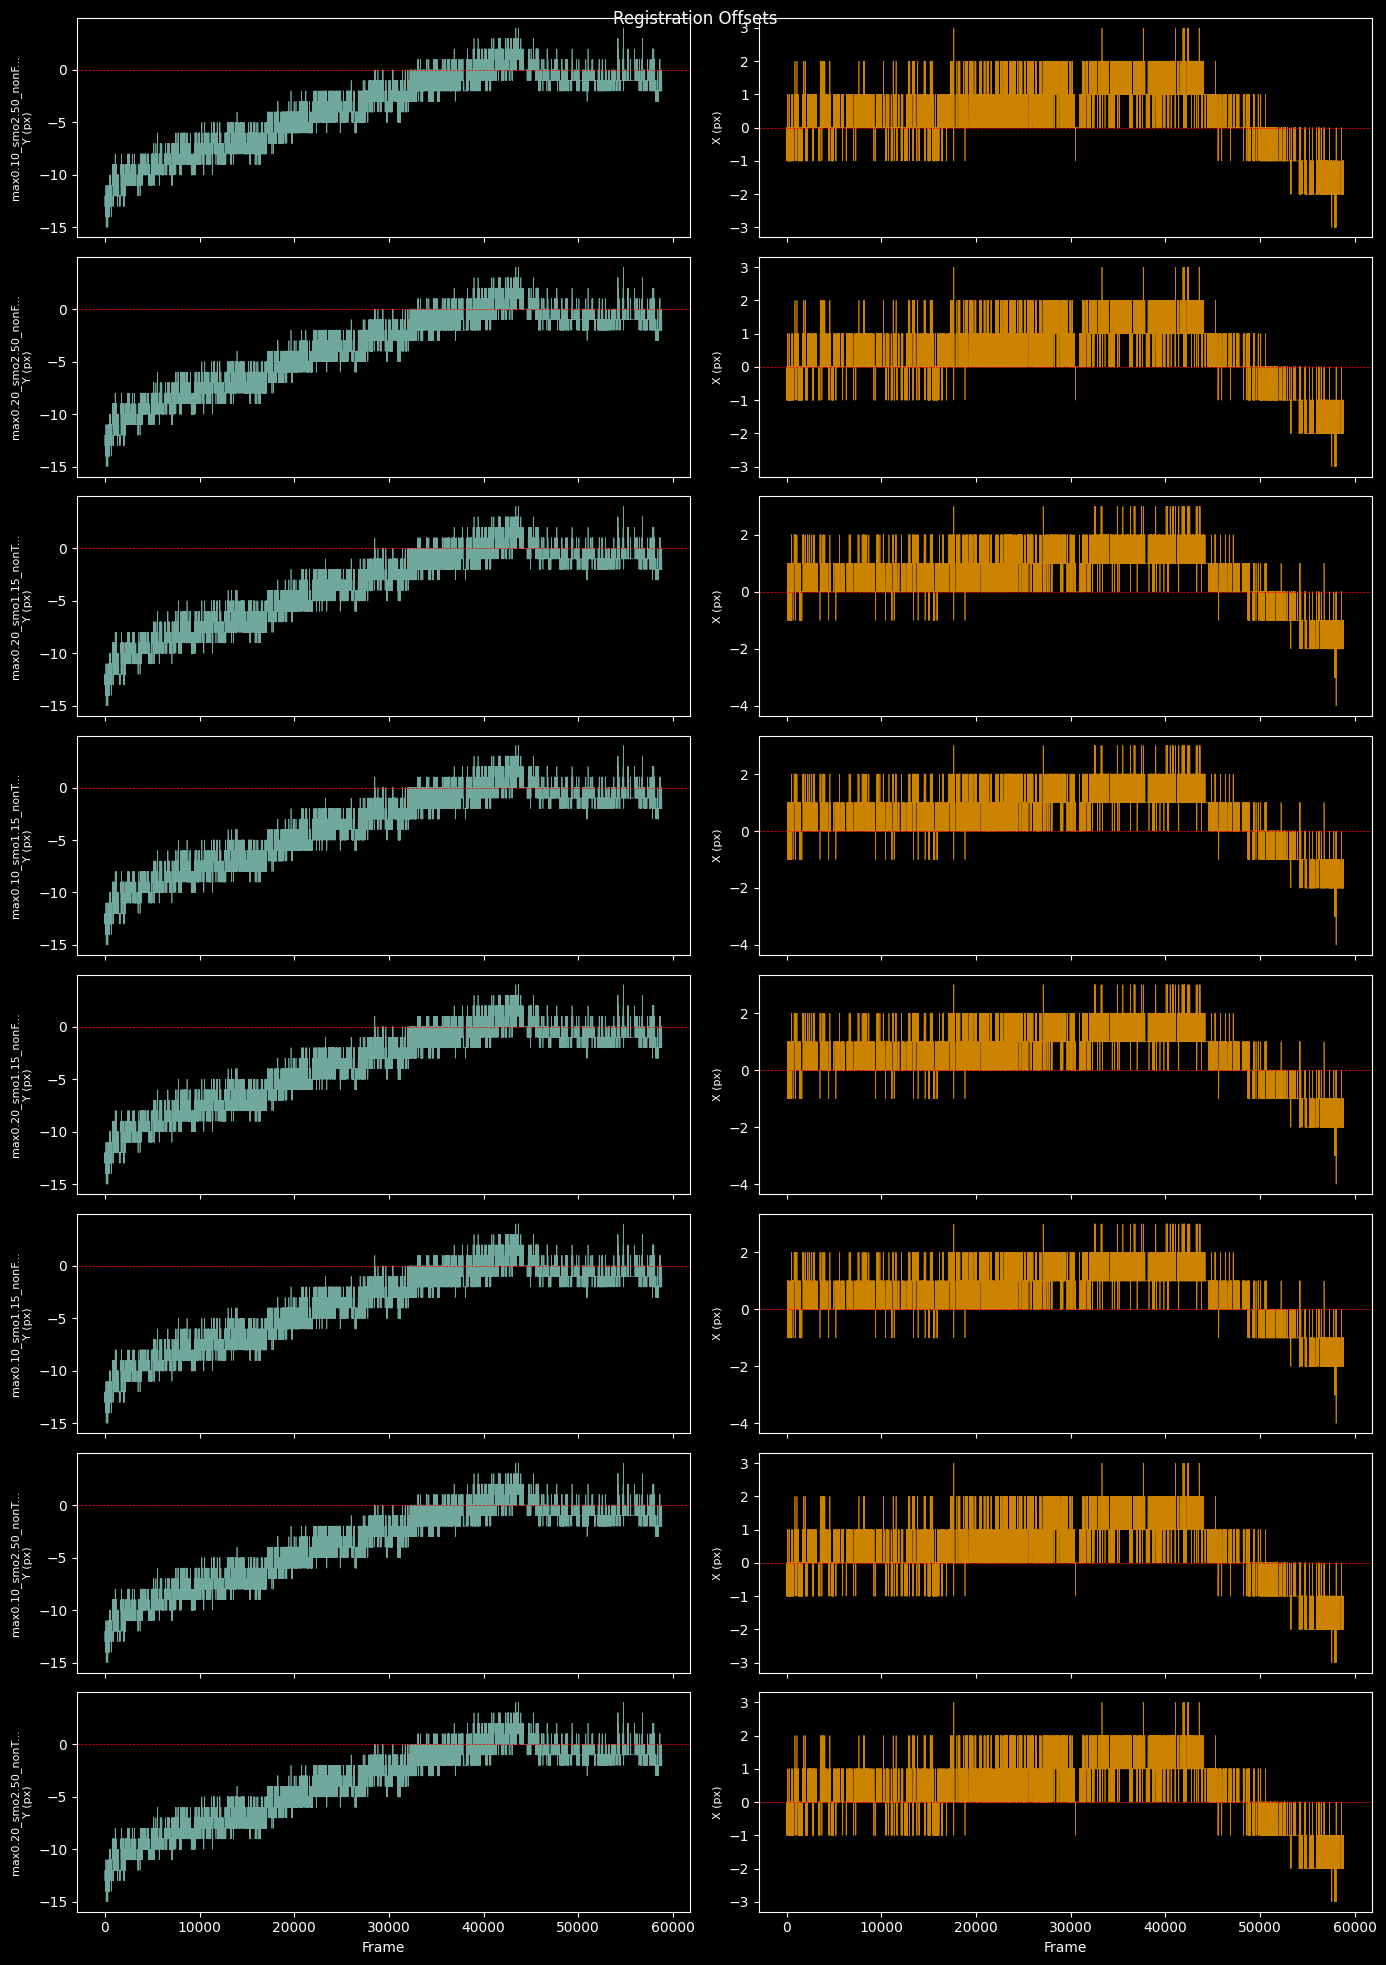

In [ ]:
n_combos = len(reg_metrics)
fig, axes = plt.subplots(n_combos, 2, figsize=(14, 2.5 * n_combos), sharex=True)
if n_combos == 1:
    axes = axes.reshape(1, -1)

for i, (name, m) in enumerate(reg_metrics.items()):
    yoff, xoff = m["yoff"], m["xoff"]
    frames = np.arange(len(yoff))

    axes[i, 0].plot(frames, yoff, lw=0.5, alpha=0.8)
    axes[i, 0].axhline(0, color="red", lw=0.5, ls="--")
    axes[i, 0].set_ylabel(f"{name[:20]}...\nY (px)" if len(name) > 20 else f"{name}\nY (px)", fontsize=8)

    axes[i, 1].plot(frames, xoff, lw=0.5, alpha=0.8, color="orange")
    axes[i, 1].axhline(0, color="red", lw=0.5, ls="--")
    axes[i, 1].set_ylabel("X (px)", fontsize=8)

axes[-1, 0].set_xlabel("Frame")
axes[-1, 1].set_xlabel("Frame")
fig.suptitle("Registration Offsets", fontsize=12)
plt.tight_layout()
plt.savefig(save_path / "registration_offsets.png", dpi=150, bbox_inches="tight")
plt.show()

## Compare Mean Images

Sharper = better registration.

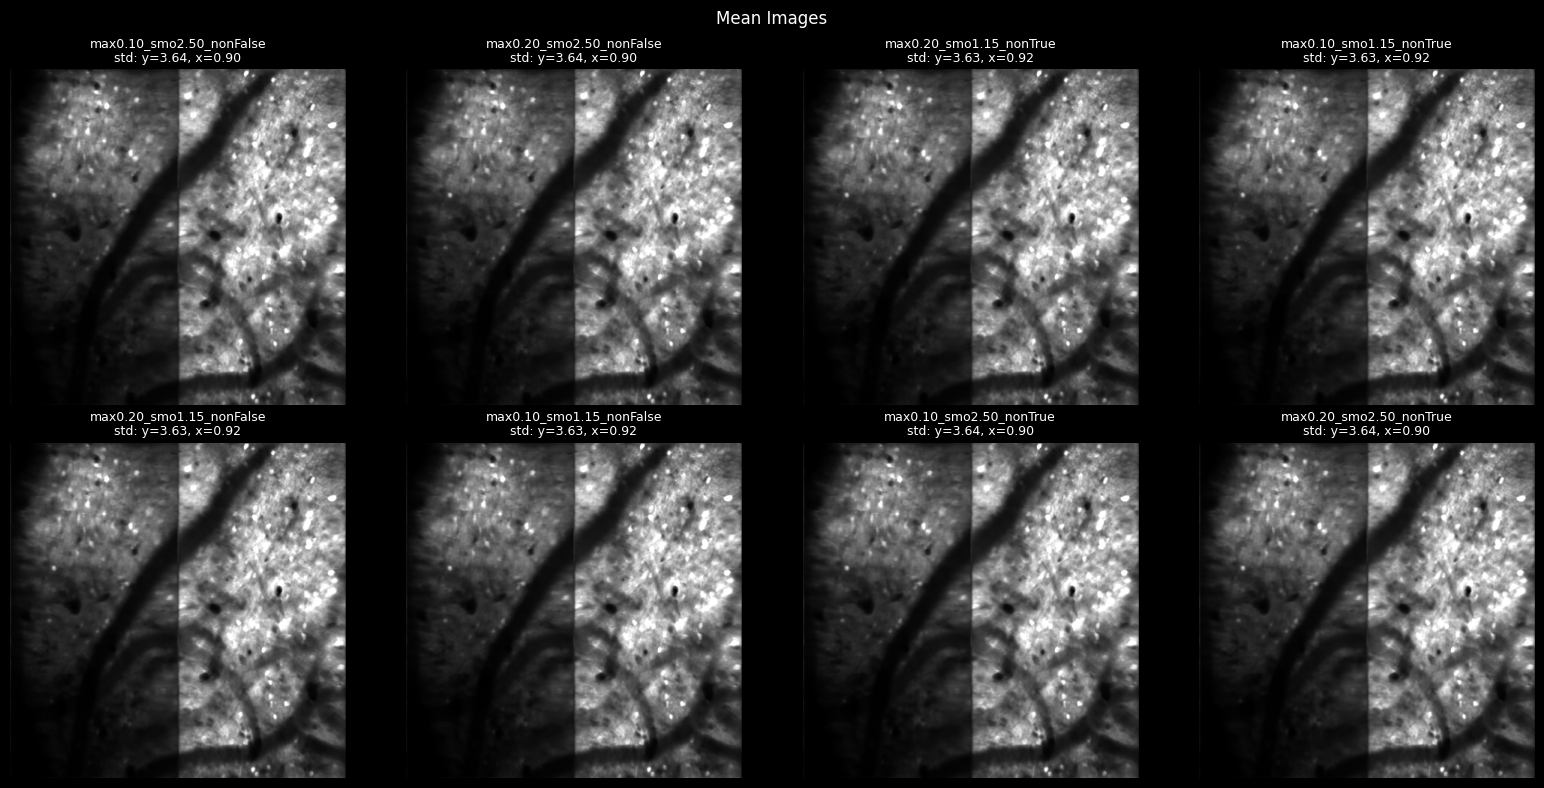

In [ ]:
n_cols = min(4, len(reg_metrics))
n_rows = (len(reg_metrics) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes).flatten()

for i, (name, m) in enumerate(reg_metrics.items()):
    ops = m["ops"]
    mean_img = ops.get("meanImg", ops.get("meanImgE", np.zeros((100, 100))))

    vmin, vmax = np.percentile(mean_img, [1, 99])
    axes[i].imshow(mean_img, cmap="gray", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"{name}\nstd: y={m['y_std']:.2f}, x={m['x_std']:.2f}", fontsize=9)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Mean Images", fontsize=12)
plt.tight_layout()
plt.savefig(save_path / "mean_images.png", dpi=150, bbox_inches="tight")
plt.show()

## Trace Quality Check

High cross-cell variance = registration artifacts (many cells spike together).

In [ ]:
def compute_frame_variance(combo_dir):
    """compute cross-cell variance per frame"""
    F = np.load(combo_dir / "F.npy")
    iscell = np.load(combo_dir / "iscell.npy")

    mask = iscell[:, 0].astype(bool)
    F_cells = F[mask]

    if len(F_cells) < 5:
        return None

    F0 = np.percentile(F_cells, 20, axis=1, keepdims=True)
    dff = (F_cells - F0) / (F0 + 1e-6)

    return dff.var(axis=0)

# collect frame variance
frame_vars = {}
for combo_name in df["combo"].values:
    combo_dir = save_path / combo_name
    fv = compute_frame_variance(combo_dir)
    if fv is not None:
        frame_vars[combo_name] = fv

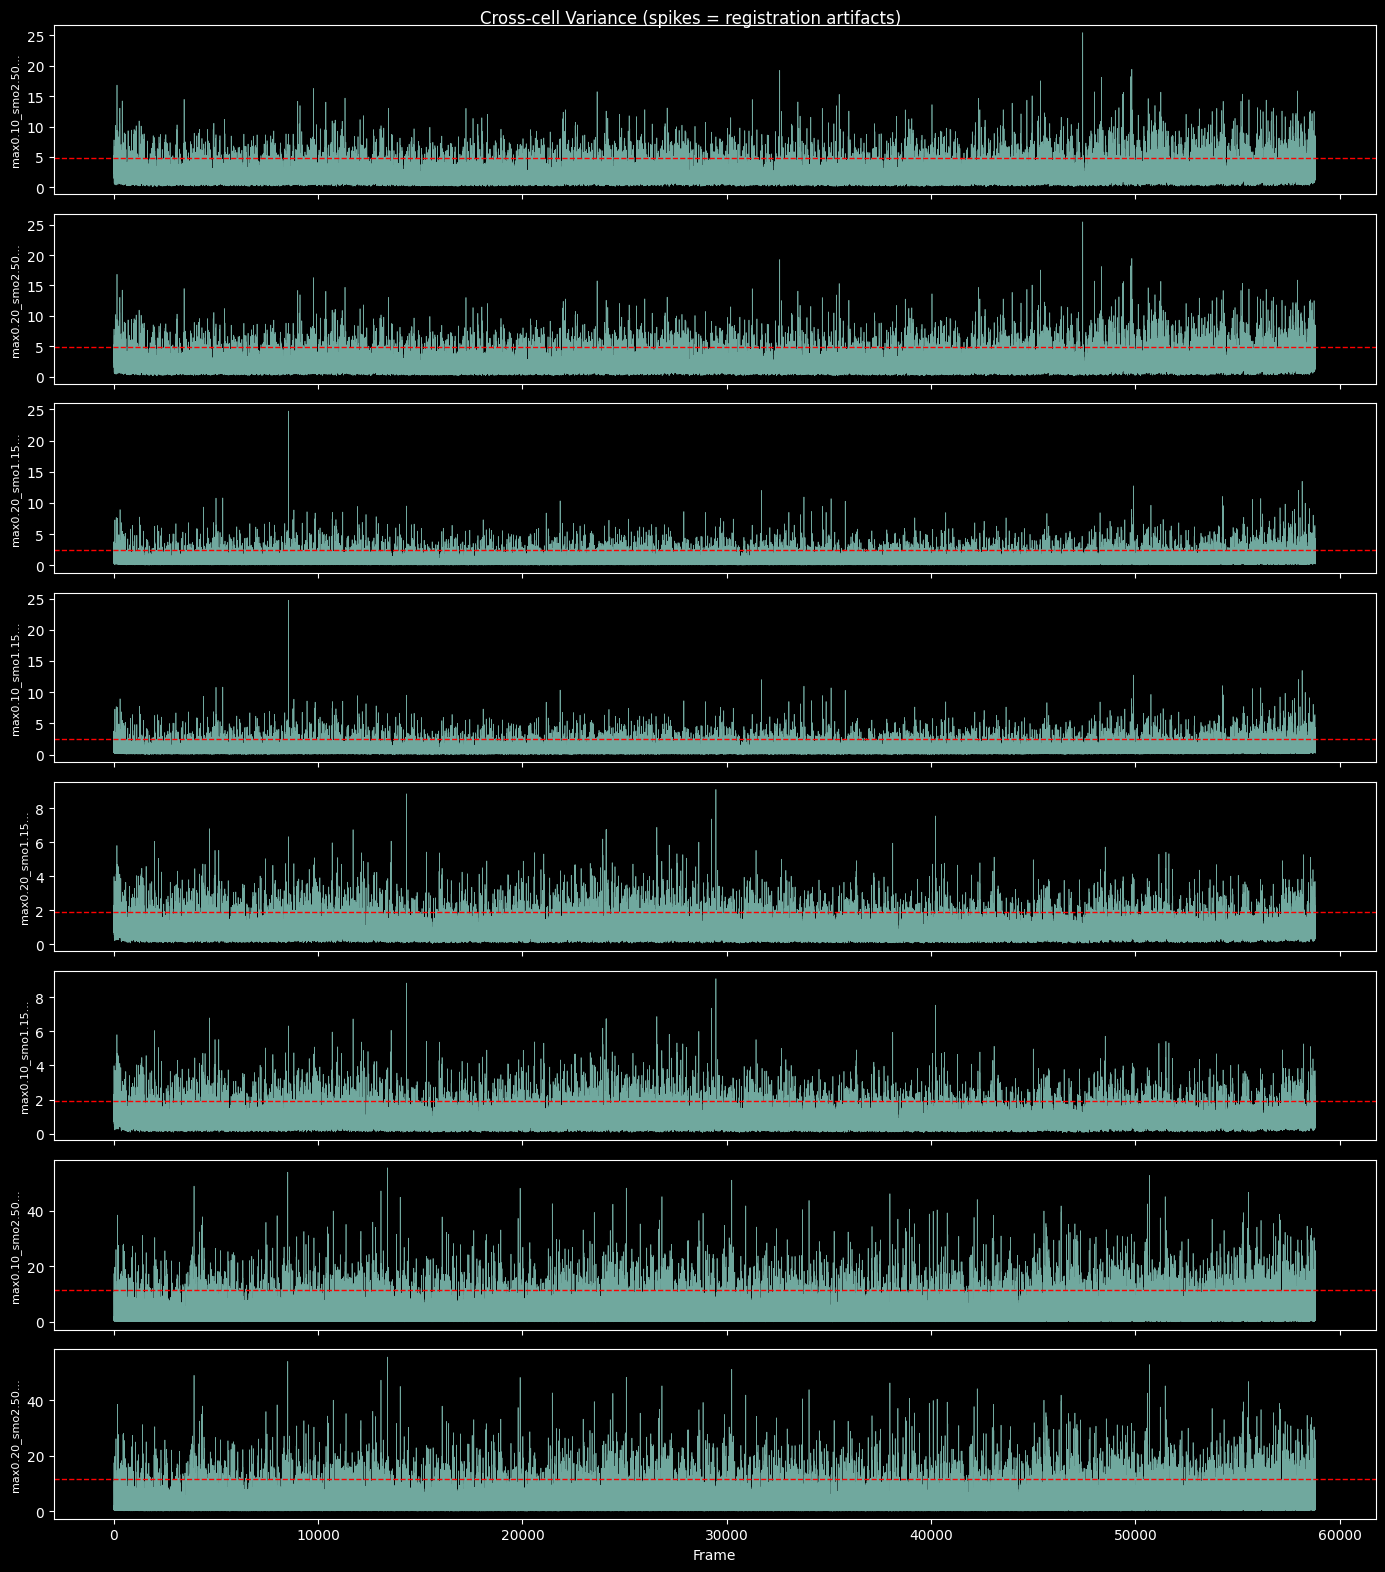

In [ ]:
fig, axes = plt.subplots(len(frame_vars), 1, figsize=(14, 2 * len(frame_vars)), sharex=True)
if len(frame_vars) == 1:
    axes = [axes]

for i, (name, fv) in enumerate(frame_vars.items()):
    axes[i].plot(fv, lw=0.5, alpha=0.8)
    axes[i].axhline(np.percentile(fv, 95), color="red", lw=1, ls="--")
    axes[i].set_ylabel(f"{name[:15]}..." if len(name) > 15 else name, fontsize=8)

axes[-1].set_xlabel("Frame")
fig.suptitle("Cross-cell Variance (spikes = registration artifacts)", fontsize=12)
plt.tight_layout()
plt.savefig(save_path / "frame_variance.png", dpi=150, bbox_inches="tight")
plt.show()

## Best Parameters

In [ ]:
lsp.print_best_parameters(df, grid_params)

AttributeError: module 'lbm_suite2p_python' has no attribute 'print_best_parameters'

## Standard Grid Search Visualizations

Saved: X:\lbm\kbarber\2025-11-04-mk311\reg_exploration\quality_metrics.png


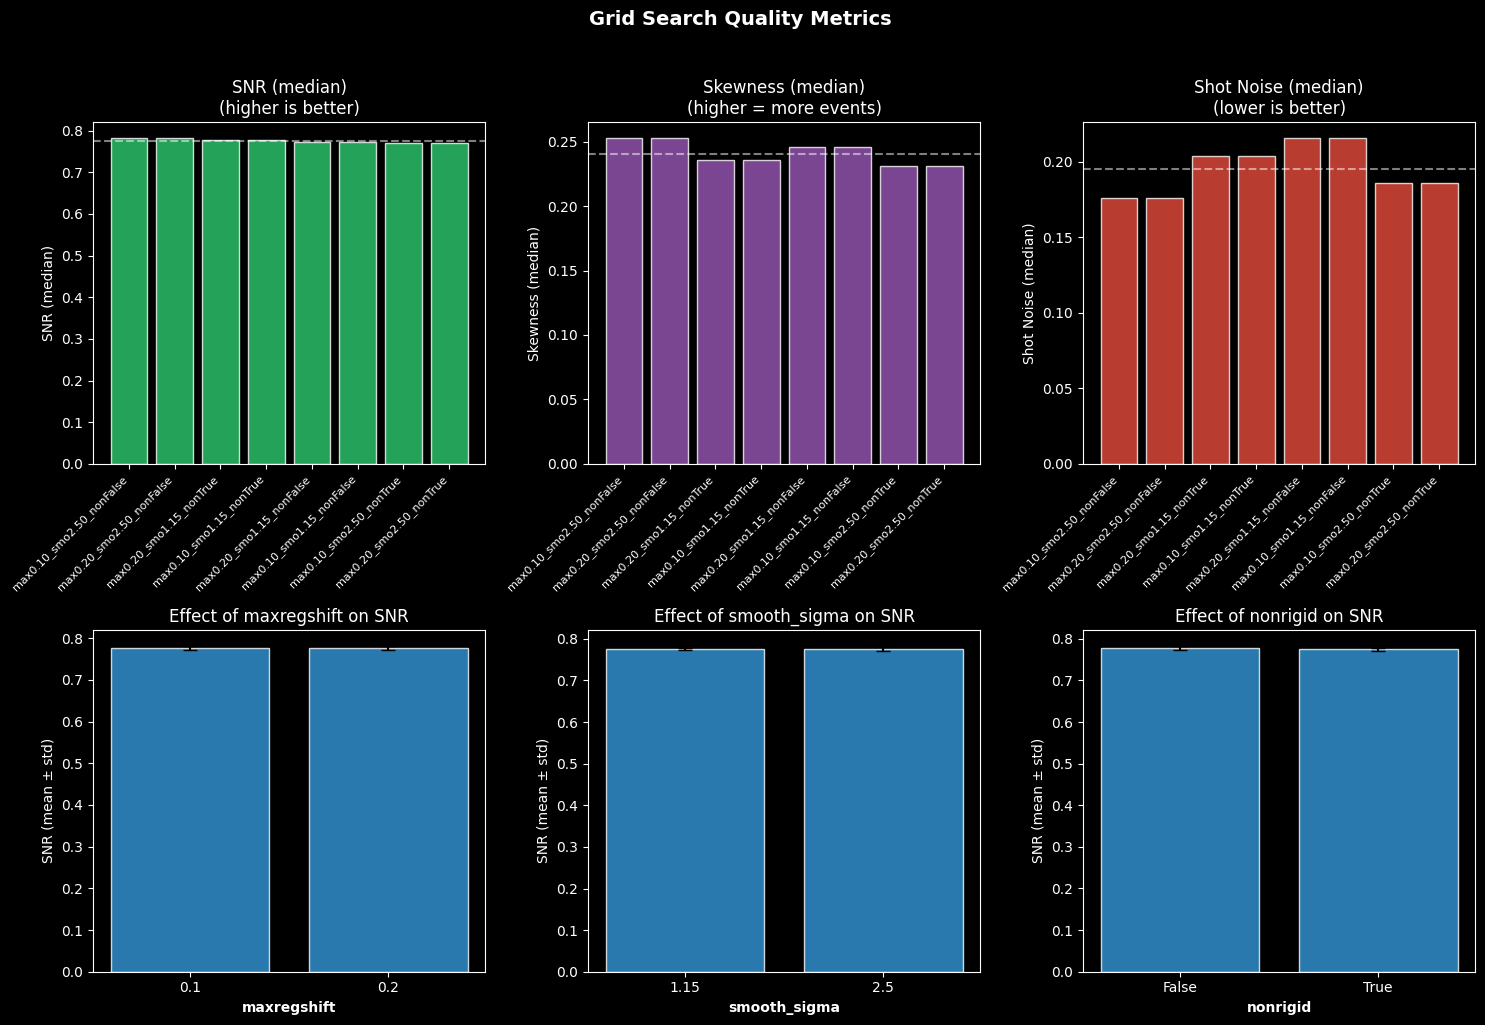

In [ ]:
lsp.plot_grid_metrics(df, grid_params, save_path=save_path / "quality_metrics.png")

In [ ]:
lsp.plot_grid_distributions(df, results_dir=save_path, n_top=4, save_path=save_path / "distributions.png")

AttributeError: module 'lbm_suite2p_python' has no attribute 'plot_grid_distributions'

In [ ]:
lsp.plot_grid_masks(df, results_dir=save_path, n_top=4, save_path=save_path / "masks.png")

AttributeError: module 'lbm_suite2p_python' has no attribute 'plot_grid_masks'

## Apply Best to Full Volume

Once you identify the best parameter set, apply to all planes.

In [ ]:
best = lsp.get_best_parameters(df)

# use best SNR parameters
best_reg_ops = {k: best["best_snr"][k] for k in grid_params.keys()}
print(f"Best registration parameters (by SNR): {best_reg_ops}")

# uncomment to run on full volume:
# full_ops = {**ops, **best_reg_ops}
# lsp.pipeline(
#     input_data=input_data,
#     save_path=save_path.parent / "suite2p_optimized",
#     ops=full_ops,
#     planes=None,  # all planes
#     force_reg=True,
# )

AttributeError: module 'lbm_suite2p_python' has no attribute 'get_best_parameters'

## Interpretation Guide

**Good registration:**
- Low offset std (< 2-3 px)
- Smooth offset traces
- Sharp mean image
- Low cross-cell frame variance

**Parameter recommendations:**

| Issue | Try |
|-------|-----|
| Large sample motion | `maxregshift=0.2-0.3`, `maxregshiftNR=10` |
| Low SNR | `smooth_sigma=2-3`, `two_step_registration=True` |
| Local distortions | `block_size=[64, 64]` |
| Non-rigid over-correcting | `nonrigid=False` or `snr_thresh=2.0` |